Companies House Data Science Workflow - Officer Nationality Analysis, Cleaning and Visualisation

Notebook Setup

In [2]:
# Install required libraries
!python -m pip install pandas seaborn matplotlib python-Levenshtein fuzzywuzzy requests


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Collect Company Numbers Automatically

In [3]:
import requests
import time

API_KEY = "bb873cea-13da-461d-9174-0838e66d4889"

queries = [
    "services",
    "consulting",
    "group",
    "holdings",
    "solutions",
    "management"
]

company_numbers = []

items_per_page = 100

for query in queries:

    start_index = 0

    while start_index < 300:   # limit per query

        url = f"https://api.company-information.service.gov.uk/search/companies?q={query}&items_per_page={items_per_page}&start_index={start_index}"

        response = requests.get(url, auth=(API_KEY, ""))

        if response.status_code != 200:
            break

        data = response.json()

        items = data.get("items", [])

        for company in items:

            number = company.get("company_number")

            if number and number not in company_numbers:
                company_numbers.append(number)

        start_index += items_per_page

        time.sleep(0.2)

print("Total unique companies:", len(company_numbers))

Total unique companies: 1800


Inspect Company List

In [4]:
company_numbers[:10]

['01692903',
 'SC423883',
 '16363569',
 '16002655',
 '15306682',
 '16086181',
 '14269085',
 '14272739',
 '14144630',
 '14236016']

Reduce Number of Companies

In [5]:
company_numbers = company_numbers[:1000]

print(len(company_numbers))

1000


Pull Officers for All Companies

In [6]:
officer_records = []

base_url = "https://api.company-information.service.gov.uk/company"

for company in company_numbers:

    start_index = 0
    items_per_page = 100

    while True:

        url = f"{base_url}/{company}/officers?items_per_page={items_per_page}&start_index={start_index}"

        response = requests.get(url, auth=(API_KEY, ""))

        if response.status_code != 200:
            break

        data = response.json()

        officers = data.get("items", [])

        if not officers:
            break

        for officer in officers:

            officer_records.append({
                "company_number": company,
                "name": officer.get("name"),
                "role": officer.get("officer_role"),
                "nationality": officer.get("nationality")
            })

        start_index += items_per_page

        time.sleep(0.2)

print("Total officers collected:", len(officer_records))

Total officers collected: 2441


Create DF

In [7]:
import pandas as pd

df = pd.DataFrame(officer_records)

df.head()

df.shape

(2441, 4)

Save Raw Dataset

In [8]:
df.to_csv("raw_officer_data.csv", index=False)

Identify Missing Data

In [9]:
df["nationality"].isna().sum()

np.int64(360)

Visualise Missing Data

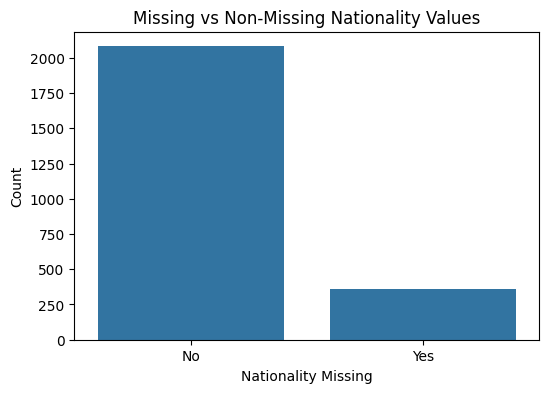

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

df['nationality_missing'] = df['nationality'].isna()

df['nationality_missing'].value_counts()

plt.figure(figsize=(6, 4))

sns.countplot(data=df, x='nationality_missing')

plt.title('Missing vs Non-Missing Nationality Values')
          
plt.xlabel('Nationality Missing')
plt.ylabel('Count')
plt.xticks([0, 1], ['No', 'Yes'])  
plt.show()


nationality_missing
False    2081
True      360
Name: count, dtype: int64


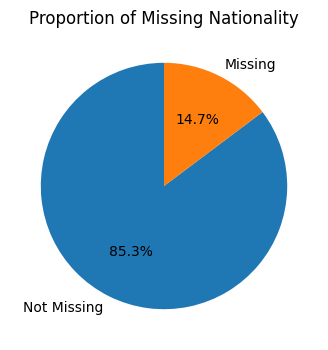

In [11]:
missing_counts = df['nationality_missing'].value_counts()

print(missing_counts)

plt.figure(figsize=(6, 4))
           
plt.pie(missing_counts, labels=['Not Missing', 'Missing'], autopct='%1.1f%%', startangle=90)

plt.title('Proportion of Missing Nationality')

plt.show()

Explore Nationality Variations

In [12]:
print(df["nationality"].value_counts().to_string())

nationality
British                              1599
French                                 38
Romanian                               36
Pakistani                              31
English                                27
South African                          24
Polish                                 24
American                               22
Indian                                 18
Irish                                  16
Dutch                                  14
Italian                                14
German                                 11
Australian                             11
Portuguese                             10
Moroccan                               10
Belgian                                 9
Bulgarian                               9
Brazilian                               9
Mauritian                               9
Nigerian                                8
Turkish                                 6
New Zealander                           6
Welsh                 

Normalise Nationality Formatting

In [13]:
df['nationality_normalized'] = (df['nationality']).str.strip().str.lower()

Mapping Dictionary

In [14]:
mapping = {
    "english": "british", 'scottish': 'british', 'welsh': 'british', 'brtish': 'british', 'nigerien':'nigerian', 'usa':'american','new zealand':'new zealander'}

df['nationality_clean'] = df['nationality_normalized'].replace(mapping)

In [15]:
df['nationality_clean'].value_counts()

nationality_clean
british               1636
french                  38
romanian                36
pakistani               31
south african           24
                      ... 
ivorian                  1
bangladeshi              1
nepalese                 1
cameroonian              1
british,australian       1
Name: count, Length: 68, dtype: int64

Convert to Categorical

In [16]:
df["nationality_clean"] = df["nationality_clean"].astype("category")

British vs Non-British Groupby Analysis

In [17]:
df["role_nationality"] = df["nationality_clean"].apply(
    lambda x: "British" if x == "british" else "Non-British"
)

In [18]:
role_nationality = df.groupby(["role","role_nationality"]).size().reset_index(name="count")

role_nationality

,role,role_nationality,count
0,director,British,1477
1,director,Non-British,435
2,nominee-director,British,2
3,secretary,British,157
4,secretary,Non-British,10


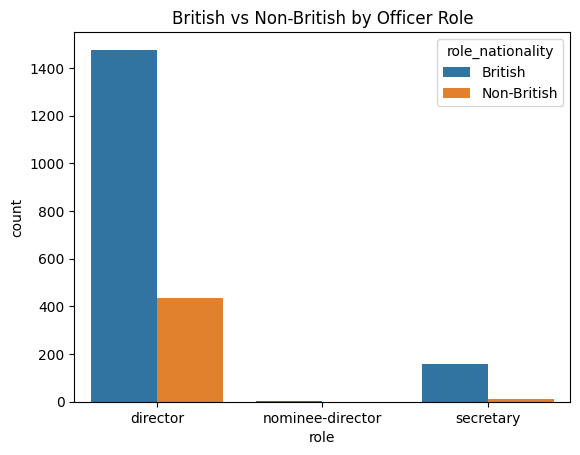

In [19]:
sns.barplot(
    data=role_nationality,
    x="role",
    y="count",
    hue="role_nationality"
)

plt.title("British vs Non-British by Officer Role")

plt.show()

In [20]:
percentage = df.groupby("role")["role_nationality"].value_counts(normalize=True)

percentage

role              role_nationality
director          British             0.77249
                  Non-British         0.22751
nominee-director  British             1.00000
secretary         British             0.94012
                  Non-British         0.05988
Name: proportion, dtype: float64

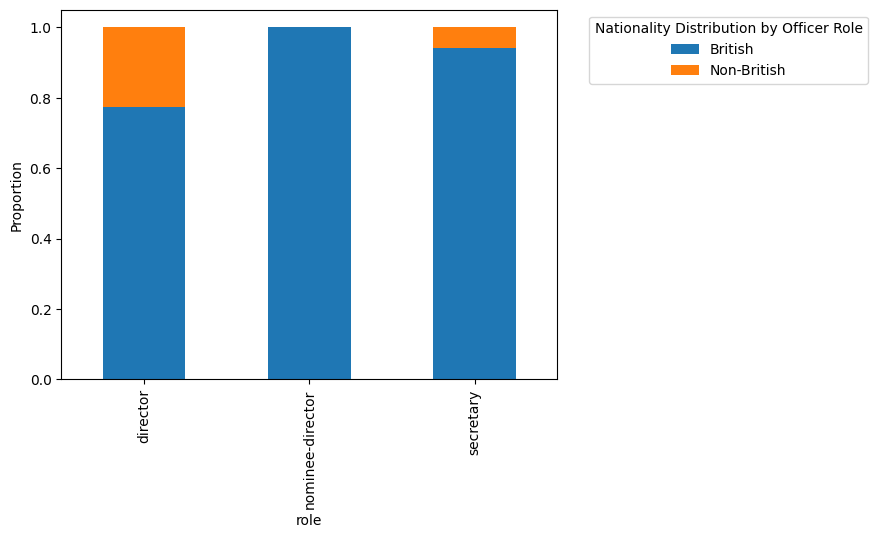

In [41]:
percentage.unstack().plot(kind="bar", stacked=True)

plt.ylabel("Proportion")

plt.legend(title="Nationality Distribution by Officer Role", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

Continent Groupby Analysis

In [42]:
continent_mapping = {

    # Europe
    "british": "Europe",
    "irish": "Europe",
    "northern irish": "Europe",
    "french": "Europe",
    "romanian": "Europe",
    "italian": "Europe",
    "polish": "Europe",
    "dutch": "Europe",
    "ukrainian": "Europe",
    "portuguese": "Europe",
    "greek": "Europe",
    "german": "Europe",
    "spanish": "Europe",
    "latvian": "Europe",
    "swedish": "Europe",
    "moldovan": "Europe",
    "belgian": "Europe",
    "finnish": "Europe",
    "swiss": "Europe",
    "danish": "Europe",
    "maltese": "Europe",
    "russian": "Europe",
    "lithuanian": "Europe",
    "austrian": "Europe",
    "bulgarian": "Europe",
    "albanian": "Europe",

    # Africa
    "nigerian": "Africa",
    "moroccan": "Africa",
    "algerian": "Africa",
    "egyptian": "Africa",
    "south african": "Africa",
    "ghanaian": "Africa",
    "kenyan": "Africa",
    "tunisian": "Africa",
    "beninese": "Africa",
    "tanzanian": "Africa",
    "sierra leonean": "Africa",
    "malagasy": "Africa",

    # Asia
    "indian": "Asia",
    "pakistani": "Asia",
    "israeli": "Asia",
    "afghan": "Asia",
    "kuwaiti": "Asia",
    "yemeni": "Asia",
    "chinese": "Asia",
    "filipino": "Asia",

    # North America
    "american": "North America",
    "canadian": "North America",

    # South America
    "argentine": "South America",
    "brazilian": "South America",
    "venezuelan": "South America",
    "ecuadorean": "South America",

    # Oceania
    "australian": "Oceania",
    "new zealander": "Oceania",

    # Other / Unknown
    "other": "Other/Unknown",
    "unknown": "Other/Unknown"
}

In [43]:
df["continent"] = df["nationality_clean"].map(continent_mapping)

In [44]:
df[df["continent"].isna()]["nationality_clean"].unique()   

[NaN, 'zimbabwean', 'croatian', 'hungarian', 'british,irish', ..., 'nepalese', 'citizen of the dominican republic', 'mauritian', 'sa citizen', 'welsh,british']
Length: 17
Categories (68, object): ['afghan', 'albanian', 'algerian', 'american', ..., 'venezuelan', 'welsh,british', 'yemeni', 'zimbabwean']

In [45]:
continent_counts = df["continent"].value_counts() 
continent_counts


continent
Europe           1860
Africa             63
Asia               54
North America      28
Oceania            19
South America      14
Other/Unknown       3
Name: count, dtype: int64

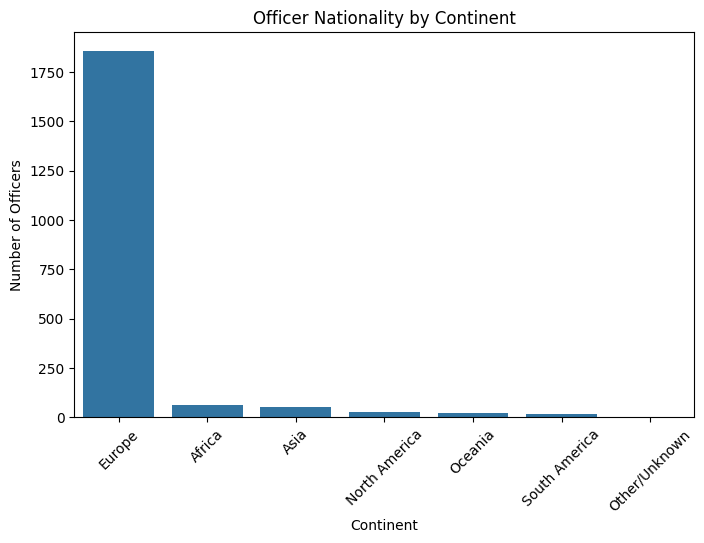

In [46]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=continent_counts.index,
    y=continent_counts.values
)

plt.title("Officer Nationality by Continent")

plt.xlabel("Continent")
plt.ylabel("Number of Officers")

plt.xticks(rotation=45)

plt.show()

FATF 'grey' and 'black' list country

In [47]:
fatf_mapping = {

    # Black list
    "northern korean": "Black List",
    "iranian": "Black List",
    "myanmar": "Black List",

    # Grey list
    "algerian": "Grey List",
    "angolan": "Grey List",
    "bolivian": "Grey List",
    "bulgarian": "Grey List",
    "cameroonian": "Grey List",
    "ivory coast": "Grey List",
    "congolese": "Grey List",
    "haitian": "Grey List",
    "kenyan": "Grey List",
    "kuwaiti": "Grey List",
    "laoan": "Grey List",
    "lebanese": "Grey List",
    "namibian": "Grey List",
    "nepalese": "Grey List",
    "south sudanese": "Grey List",
    "papa new guinean": "Grey List",
    "syrian": "Grey List",
    "venezuelan": "Grey List",
    "vietnamese": "Grey List",
    "yemeni": "Grey List",

}

In [48]:
df["fatf_status"] = df["nationality_clean"].map(fatf_mapping)
df["fatf_status"] = df["fatf_status"].fillna("Not Listed")

In [49]:
df["fatf_status"].value_counts()

fatf_status
Not Listed    2420
Grey List       21
Name: count, dtype: int64

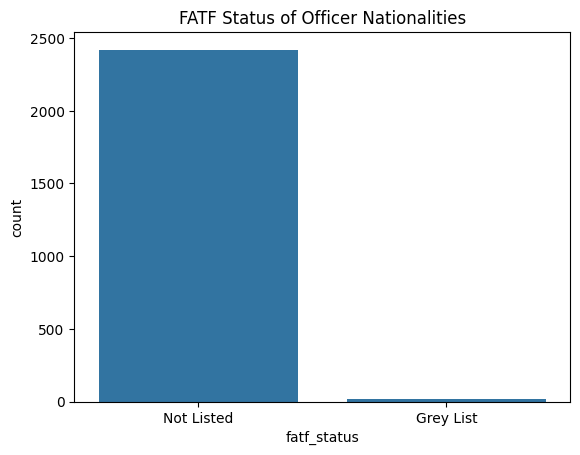

In [50]:
sns.countplot(data=df, x="fatf_status")
plt.title("FATF Status of Officer Nationalities")
plt.show()